## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [2]:
from models.PINN import get_systolic_peak,calculate_derivatives, get_dicrotic_notch, extract_delay_times, get_delay_time, prepare_UCI_dataset, estimate_RC

In [3]:
FS = 125
WINDOW_SIZE = 1000

MAT_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/data/Part_1.mat"
f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================

notches = []

for sys_idx in sys_peaks:

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 54 119 184 249 312 377 442 506 569 633 697 761 824 886 950]

Detected landmarks:
Beat 1: Systolic = 54 (0.432 s), Notch = 74
Beat 2: Systolic = 119 (0.952 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 249 (1.992 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 442 (3.536 s), Notch = 461
Beat 8: Systolic = 506 (4.048 s), Notch = 526
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 697 (5.576 s), Notch = 716
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 886 (7.088 s), Notch = 907
Beat 15: Systolic = 950 (7.600 s), Notch = 970

Peak → notch delays:
Beat 1: 0.160 seconds
Beat 2: 0.152 seconds
Beat 3: 0.152 secon

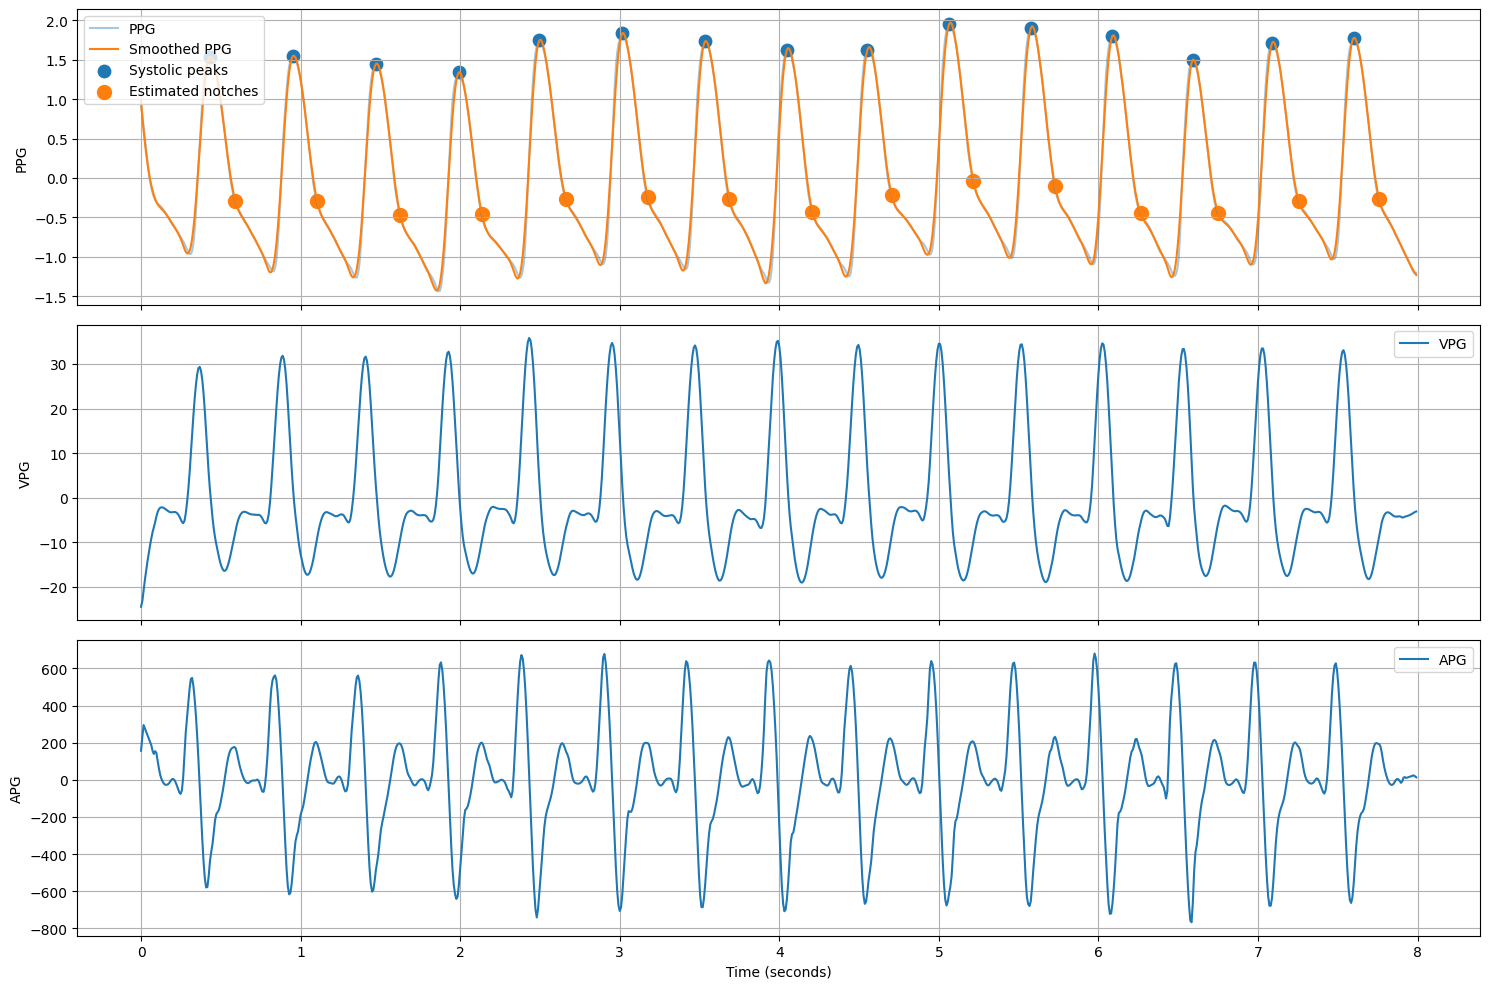

In [4]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [5]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.16  0.152 0.152 0.144 0.168 0.16  0.152 0.16  0.152 0.152 0.152 0.176
 0.16  0.168 0.16 ]


In [6]:
DATA_PATH = (
    "/data1/yashvi_bhuva/"
    "BP_estimation_using_PPG/UCI/data")
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset(
    data_path=DATA_PATH)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [37:11<00:00,  3.76it/s]  


Skipped recordings: 4

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [05:23<00:00,  3.71it/s]


Skipped recordings: 0

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [10:57<00:00,  3.65it/s]


Skipped recordings: 1

DATASET SHAPES
X_train: torch.Size([454999, 1, 1000])
y_train: torch.Size([454999, 2])
delay_train: torch.Size([454999])
X_val: torch.Size([65488, 1, 1000])
y_val: torch.Size([65488, 2])
delay_val: torch.Size([65488])
X_test: torch.Size([133602, 1, 1000])
y_test: torch.Size([133602, 2])
delay_test: torch.Size([133602])


In [7]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([454999])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 454999

Statistics:
Min    : 0.088
Max    : 0.336
Mean   : 0.18123685
Median : 0.18
Std    : 0.03676362

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 454999

Percentiles:
 1% : 0.112
 5% : 0.128
25% : 0.152
50% : 0.18
75% : 0.208
95% : 0.244
99% : 0.28


/tmp/ipykernel_2025421/1836814138.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("NaN count:", np.isnan(delay_train).sum())


/tmp/ipykernel_2025421/2105359308.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.isfinite(delay_train)
/tmp/ipykernel_2025421/2105359308.py:3: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  valid_delay = delay_train[


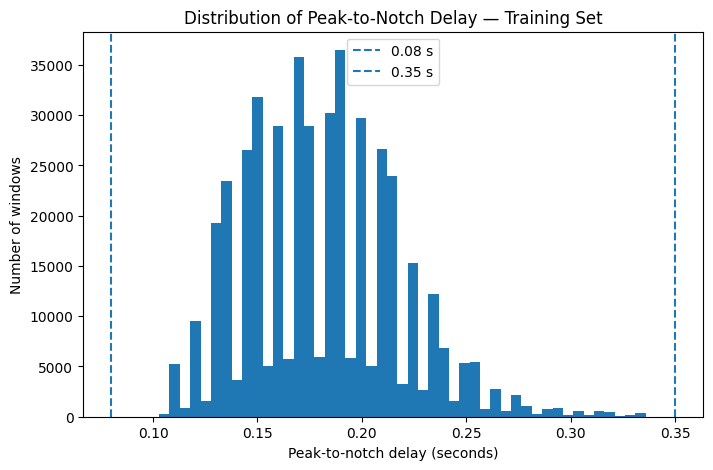

In [8]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [9]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([454999, 1, 1000])
y_train: torch.Size([454999, 2])
delay_train: torch.Size([454999])
Number of windows: 454999
Number of BP labels: 454999
Number of delays: 454999


/tmp/ipykernel_2025421/3737023816.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_train[np.isfinite(delay_train), 0],
/tmp/ipykernel_2025421/3737023816.py:5: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  y_train[np.isfinite(delay_train), 0],


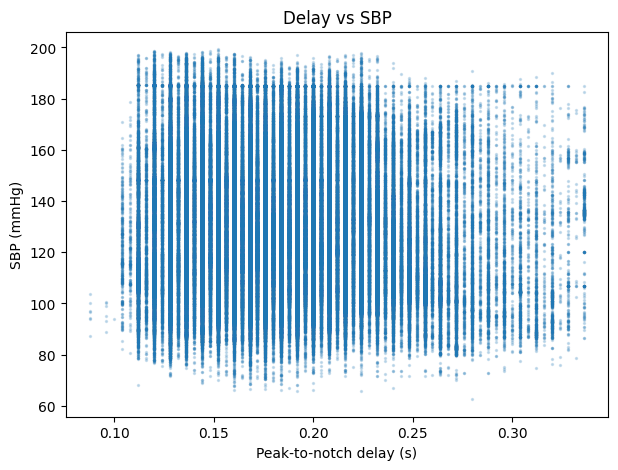

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

/tmp/ipykernel_2025421/3149313679.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_train[np.isfinite(delay_train), 1],
/tmp/ipykernel_2025421/3149313679.py:5: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  y_train[np.isfinite(delay_train), 1],


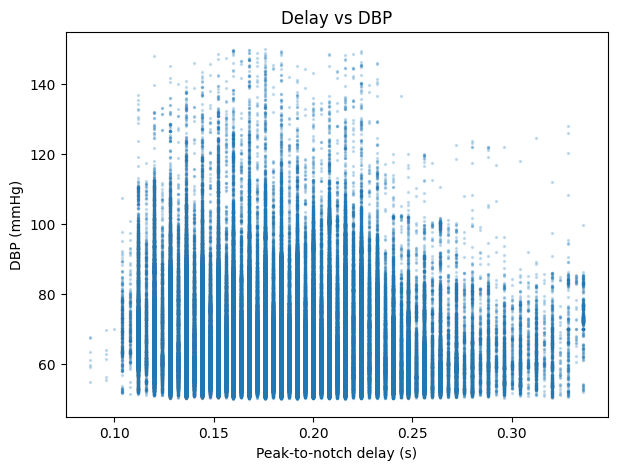

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [12]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 454999
Valid windows: 454999
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2696 s
Mean RC   : 0.2994 s
Std RC    : 0.1486 s
Min RC    : 0.1104 s
Max RC    : 4.6139 s


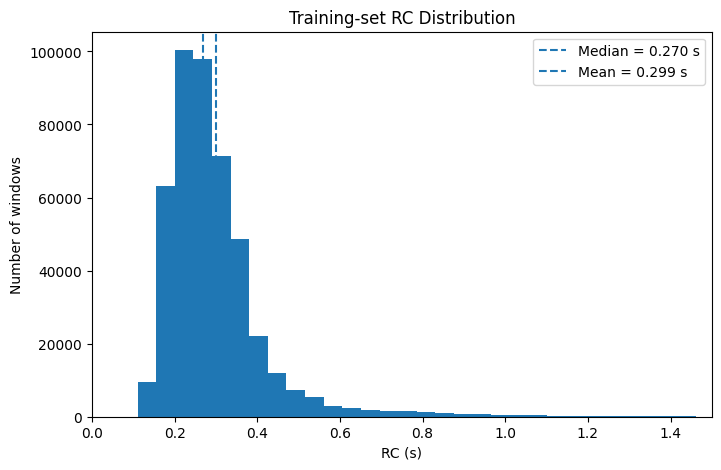

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [14]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1465 s
  5.0% : 0.1700 s
 25.0% : 0.2200 s
 50.0% : 0.2696 s
 75.0% : 0.3348 s
 90.0% : 0.4159 s
 95.0% : 0.5160 s
 99.0% : 0.8912 s
 99.5% : 1.1039 s
 99.9% : 1.7313 s


In [15]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 11.705462
Physics-only DBP RMSE: 14.986806


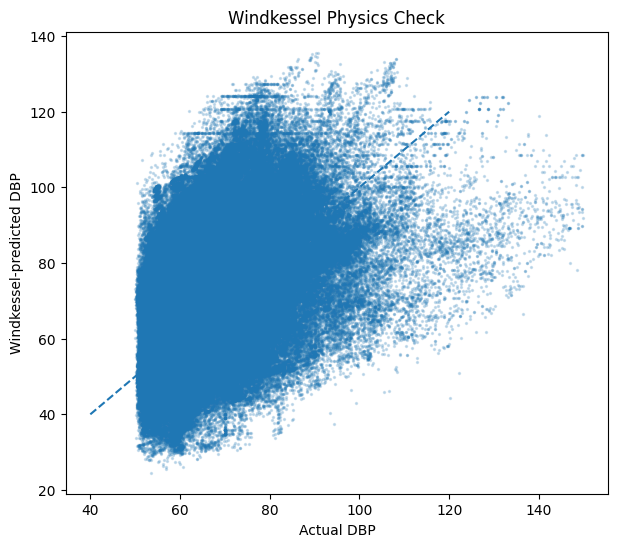

In [16]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [17]:
def grid_search_RC(
    sbp,
    dbp,
    delay,
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
):

    sbp = np.asarray(sbp, dtype=np.float64)
    dbp = np.asarray(dbp, dtype=np.float64)
    delay = np.asarray(delay, dtype=np.float64)

    # -----------------------------------------
    # Valid samples
    # -----------------------------------------

    valid = (
        np.isfinite(sbp) &
        np.isfinite(dbp) &
        np.isfinite(delay) &
        (sbp > 0) &
        (dbp > 0) &
        (dbp < sbp)
    )

    sbp = sbp[valid]
    dbp = dbp[valid]
    delay = delay[valid]

    print("Valid samples:", len(sbp))

    # -----------------------------------------
    # Candidate RC values
    # -----------------------------------------

    rc_values = np.arange(
        rc_min,
        rc_max + rc_step,
        rc_step
    )

    mae_values = []
    rmse_values = []

    # -----------------------------------------
    # Evaluate every RC
    # -----------------------------------------

    for RC in rc_values:

        dbp_physics = (
            sbp *
            np.exp(-delay / RC)
        )

        mae = np.mean(
            np.abs(dbp_physics - dbp)
        )

        rmse = np.sqrt(
            np.mean(
                (dbp_physics - dbp) ** 2
            )
        )

        mae_values.append(mae)
        rmse_values.append(rmse)

    mae_values = np.array(mae_values)
    rmse_values = np.array(rmse_values)

    # -----------------------------------------
    # Best RC
    # -----------------------------------------

    best_mae_idx = np.argmin(mae_values)
    best_rmse_idx = np.argmin(rmse_values)

    best_RC_MAE = rc_values[best_mae_idx]
    best_RC_RMSE = rc_values[best_rmse_idx]

    print("\n======================================")
    print("RC GRID SEARCH RESULTS")
    print("======================================")

    print(
        f"Best RC by MAE  : {best_RC_MAE:.4f} s"
    )

    print(
        f"Best MAE        : {mae_values[best_mae_idx]:.4f} mmHg"
    )

    print()

    print(
        f"Best RC by RMSE : {best_RC_RMSE:.4f} s"
    )

    print(
        f"Best RMSE       : {rmse_values[best_rmse_idx]:.4f} mmHg"
    )

    return (
        rc_values,
        mae_values,
        rmse_values,
        best_RC_MAE,
        best_RC_RMSE
    )

rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 454999

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2650 s
Best MAE        : 10.9881 mmHg

Best RC by RMSE : 0.2650 s
Best RMSE       : 14.0587 mmHg


## Establishing Baseline using 1D ResNet ##

In [20]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([454999, 1, 1000])
y_train: torch.Size([454999, 2])
X_val: torch.Size([65488, 1, 1000])
y_val: torch.Size([65488, 2])
X_test: torch.Size([133602, 1, 1000])
y_test: torch.Size([133602, 2])


In [22]:
class PPGDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]


train_dataset = PPGDataset(
    X_train,
    y_train
)

val_dataset = PPGDataset(
    X_val,
    y_val
)

test_dataset = PPGDataset(
    X_test,
    y_test
)
BATCH_SIZE = 256

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [28]:
class BasicBlock1D(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        # ------------------------------------------------
        # First convolution
        # ------------------------------------------------

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        # ------------------------------------------------
        # Second convolution
        # ------------------------------------------------

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=7,
            stride=1,
            padding=3,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(
            out_channels
        )

        # ------------------------------------------------
        # Skip connection
        # ------------------------------------------------

        self.downsample = None

        if (
            stride != 1
            or in_channels != out_channels
        ):

            self.downsample = nn.Sequential(

                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm1d(
                    out_channels
                )
            )


    def forward(self, x):

        identity = x

        # Main branch
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Skip branch
        if self.downsample is not None:

            identity = self.downsample(x)

        # Residual addition
        out = out + identity

        out = self.relu(out)

        return out

In [29]:
class SmallResNet1D(nn.Module):

    def __init__(self):

        super().__init__()

        # ==================================================
        # Initial channels
        # ==================================================

        self.in_channels = 32


        # ==================================================
        # Initial convolution
        # ==================================================

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=32,
            kernel_size=15,
            stride=2,
            padding=7,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(32)

        self.relu = nn.ReLU(
            inplace=True
        )

        self.maxpool = nn.MaxPool1d(
            kernel_size=3,
            stride=2,
            padding=1
        )


        # ==================================================
        # Residual stages
        # ==================================================

        self.layer1 = self._make_layer(
            out_channels=32,
            blocks=2,
            stride=1
        )

        self.layer2 = self._make_layer(
            out_channels=64,
            blocks=2,
            stride=2
        )

        self.layer3 = self._make_layer(
            out_channels=128,
            blocks=2,
            stride=2
        )

        self.layer4 = self._make_layer(
            out_channels=256,
            blocks=2,
            stride=2
        )


        # ==================================================
        # Global pooling
        # ==================================================

        self.avgpool = nn.AdaptiveAvgPool1d(1)


        # ==================================================
        # Dropout
        # ==================================================

        self.dropout = nn.Dropout(
            p=0.4
        )


        # ==================================================
        # SBP + DBP regression head
        # ==================================================

        self.fc = nn.Linear(
            256,
            2
        )


    def _make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        layers = []

        # First block
        layers.append(
            BasicBlock1D(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        # Remaining blocks
        for _ in range(1, blocks):

            layers.append(
                BasicBlock1D(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)


    def forward(self, x):

        # Input:
        # [batch, 1, 1000]

        x = self.conv1(x)

        x = self.bn1(x)

        x = self.relu(x)

        x = self.maxpool(x)


        # Residual stages

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)


        # Global average pooling

        x = self.avgpool(x)

        # [B, 256, 1]
        #
        # ->
        #
        # [B, 256]

        x = torch.flatten(
            x,
            start_dim=1
        )


        # Dropout

        x = self.dropout(x)


        # Regression

        x = self.fc(x)

        # [B, 2]
        #
        # [:,0] = SBP
        # [:,1] = DBP

        return x

In [33]:
model = SmallResNet1D().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [34]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 10257.27 (SBP RMSE: 93.30, DBP RMSE: 39.40) | Val MSE: 2398.12 (SBP RMSE: 47.76, DBP RMSE: 10.83) | Improved
Epoch 2/50 | Train MSE: 815.43 (SBP RMSE: 26.41, DBP RMSE: 10.85) | Val MSE: 429.49 (SBP RMSE: 18.24, DBP RMSE: 9.84) | Improved
Epoch 3/50 | Train MSE: 382.18 (SBP RMSE: 16.86, DBP RMSE: 9.90) | Val MSE: 375.78 (SBP RMSE: 17.07, DBP RMSE: 9.19) | Improved
Epoch 4/50 | Train MSE: 327.21 (SBP RMSE: 15.55, DBP RMSE: 9.24) | Val MSE: 356.05 (SBP RMSE: 16.55, DBP RMSE: 9.06) | Improved
Epoch 5/50 | Train MSE: 293.36 (SBP RMSE: 14.68, DBP RMSE: 8.82) | Val MSE: 368.37 (SBP RMSE: 17.02, DBP RMSE: 8.88) | No improvement (1/10)
Epoch 6/50 | Train MSE: 269.84 (SBP RMSE: 14.06, DBP RMSE: 8.49) | Val MSE: 332.83 (SBP RMSE: 15.97, DBP RMSE: 8.82) | Improved
Epoch 7/50 | Train MSE: 250.47 (SBP RMSE: 13.52, DBP RMSE: 8.23) | Val MSE: 346.97 (SBP RMSE: 16.39, DBP RMSE: 8.85) | No improvement (1/10)
Epoch 8/50 | Train MSE: 235.16 (SBP RMSE: 13.06, DBP RMSE: 8.04) | Val M

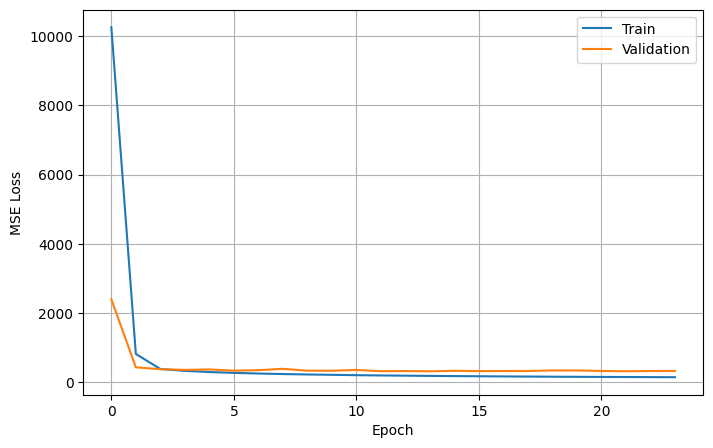

In [35]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [36]:
from models.train import evaluate_model
predictions, targets, metrics = evaluate_model(
    model,
    test_loader,
    device
)

SBP MAE: 11.18 mmHg
DBP MAE: 5.84 mmHg
SBP RMSE: 15.92 mmHg
DBP RMSE: 8.75 mmHg


## Physics Informed Windkessel ##

In [38]:
import copy

In [39]:
class PPGPhysicsDataset(Dataset):

    def __init__(self, X, y, delay):

        self.X = X
        self.y = y
        self.delay = delay

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx],
            self.delay[idx]
        )

In [40]:
BATCH_SIZE = 256

train_dataset = PPGPhysicsDataset(
    X_train,
    y_train,
    delay_train
)

val_dataset = PPGPhysicsDataset(
    X_val,
    y_val,
    delay_val
)

test_dataset = PPGPhysicsDataset(
    X_test,
    y_test,
    delay_test
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [41]:
def windkessel_physics_loss(
    predictions,
    delays,
    RC
):

    # -----------------------------------------
    # Network predictions
    # -----------------------------------------

    sbp_pred = predictions[:, 0]
    dbp_pred = predictions[:, 1]


    # -----------------------------------------
    # Windkessel-inspired DBP
    #
    # DBP_WK = SBP * exp(-delay / RC)
    # -----------------------------------------

    dbp_wk = (
        sbp_pred *
        torch.exp(
            -delays / RC
        )
    )


    # -----------------------------------------
    # Physics consistency loss
    # -----------------------------------------

    physics_loss = torch.mean(
        (
            dbp_wk - dbp_pred
        ) ** 2
    )


    return physics_loss

In [42]:
def pinn_loss(
    predictions,
    targets,
    delays,
    RC,
    lambda_phys=0.01
):

    # -----------------------------------------
    # Supervised loss
    # -----------------------------------------

    bp_loss = nn.functional.mse_loss(
        predictions,
        targets
    )


    # -----------------------------------------
    # Windkessel loss
    # -----------------------------------------

    physics_loss = windkessel_physics_loss(
        predictions,
        delays,
        RC
    )


    # -----------------------------------------
    # Total loss
    # -----------------------------------------

    total = (
        bp_loss
        +
        lambda_phys * physics_loss
    )


    return (
        total,
        bp_loss,
        physics_loss
    )

In [43]:
model = SmallResNet1D().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [47]:
EPOCHS = 50

LAMBDA_PHYS = 0.001

PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
for epoch in range(EPOCHS):

    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    train_total = 0.0
    train_bp = 0.0
    train_phys = 0.0

    train_sbp_errors = []
    train_dbp_errors = []


    for X, y, delay in train_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        delay = delay.to(
            device,
            non_blocking=True
        )


        # -----------------------------------------
        # Forward pass
        # -----------------------------------------

        predictions = model(X)


        # -----------------------------------------
        # Loss
        # -----------------------------------------

        total_loss, bp_loss, physics_loss = pinn_loss(
            predictions,
            y,
            delay,
            RC,
            lambda_phys=LAMBDA_PHYS
        )


        # -----------------------------------------
        # Backpropagation
        # -----------------------------------------

        optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        # -----------------------------------------
        # Statistics
        # -----------------------------------------

        bs = X.size(0)

        train_total += (
            total_loss.item() * bs
        )

        train_bp += (
            bp_loss.item() * bs
        )

        train_phys += (
            physics_loss.item() * bs
        )


        train_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).detach().cpu()
        )

        train_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).detach().cpu()
        )


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    n_train = len(train_dataset)

    train_total /= n_train
    train_bp /= n_train
    train_phys /= n_train

    train_sbp_errors = torch.cat(
        train_sbp_errors
    )

    train_dbp_errors = torch.cat(
        train_dbp_errors
    )

    train_sbp_rmse = torch.sqrt(
        torch.mean(
            train_sbp_errors ** 2
        )
    ).item()

    train_dbp_rmse = torch.sqrt(
        torch.mean(
            train_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_total = 0.0
    val_bp = 0.0
    val_phys = 0.0

    val_sbp_errors = []
    val_dbp_errors = []


    with torch.no_grad():

        for X, y, delay in val_loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            delay = delay.to(
                device,
                non_blocking=True
            )


            predictions = model(X)


            total_loss, bp_loss, physics_loss = pinn_loss(
                predictions,
                y,
                delay,
                RC,
                lambda_phys=LAMBDA_PHYS
            )


            bs = X.size(0)

            val_total += (
                total_loss.item() * bs
            )

            val_bp += (
                bp_loss.item() * bs
            )

            val_phys += (
                physics_loss.item() * bs
            )


            val_sbp_errors.append(
                (
                    predictions[:, 0] - y[:, 0]
                ).cpu()
            )

            val_dbp_errors.append(
                (
                    predictions[:, 1] - y[:, 1]
                ).cpu()
            )


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    n_val = len(val_dataset)

    val_total /= n_val
    val_bp /= n_val
    val_phys /= n_val

    val_sbp_errors = torch.cat(
        val_sbp_errors
    )

    val_dbp_errors = torch.cat(
        val_dbp_errors
    )

    val_sbp_rmse = torch.sqrt(
        torch.mean(
            val_sbp_errors ** 2
        )
    ).item()

    val_dbp_rmse = torch.sqrt(
        torch.mean(
            val_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        status = "Improved"

    else:

        patience_counter += 1

        status = (
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_total:.2f} "
        f"(BP: {train_bp:.2f}, "
        f"Phys: {train_phys:.2f}) | "
        f"Train SBP RMSE: {train_sbp_rmse:.2f} | "
        f"Train DBP RMSE: {train_dbp_rmse:.2f} | "
        f"Val Loss: {val_total:.2f} "
        f"(BP: {val_bp:.2f}, "
        f"Phys: {val_phys:.2f}) | "
        f"Val SBP RMSE: {val_sbp_rmse:.2f} | "
        f"Val DBP RMSE: {val_dbp_rmse:.2f} | "
        f"{status}"
    )


    # ==================================================
    # EARLY STOP
    # ==================================================

    if patience_counter >= PATIENCE:

        print("Early stopping.")

        break

Epoch 1/50 | Train Loss: 5409.34 (BP: 5409.14, Phys: 193.28) | Train SBP RMSE: 95.24 | Train DBP RMSE: 41.81 | Val Loss: 1074.40 (BP: 1073.96, Phys: 441.92) | Val SBP RMSE: 45.26 | Val DBP RMSE: 9.99 | Improved
Epoch 2/50 | Train Loss: 397.06 (BP: 396.89, Phys: 167.96) | Train SBP RMSE: 26.12 | Train DBP RMSE: 10.55 | Val Loss: 216.95 (BP: 216.87, Phys: 78.96) | Val SBP RMSE: 18.38 | Val DBP RMSE: 9.80 | Improved
Epoch 3/50 | Train Loss: 189.74 (BP: 189.64, Phys: 101.40) | Train SBP RMSE: 16.82 | Train DBP RMSE: 9.82 | Val Loss: 188.58 (BP: 188.48, Phys: 101.68) | Val SBP RMSE: 17.06 | Val DBP RMSE: 9.27 | Improved
Epoch 4/50 | Train Loss: 167.99 (BP: 167.88, Phys: 112.29) | Train SBP RMSE: 15.79 | Train DBP RMSE: 9.30 | Val Loss: 183.22 (BP: 183.11, Phys: 113.43) | Val SBP RMSE: 16.83 | Val DBP RMSE: 9.11 | Improved
Epoch 5/50 | Train Loss: 152.97 (BP: 152.85, Phys: 120.45) | Train SBP RMSE: 15.04 | Train DBP RMSE: 8.91 | Val Loss: 188.33 (BP: 188.20, Phys: 127.44) | Val SBP RMSE: 16.

In [48]:
model.load_state_dict(
    best_model_state
)

model.eval()

SmallResNet1D(
  (conv1): Conv1d(1, 32, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
   

In [49]:
test_sbp_errors = []
test_dbp_errors = []

test_predictions = []
test_targets = []


with torch.no_grad():

    for X, y, delay in test_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        predictions = model(X)

        test_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).cpu()
        )

        test_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).cpu()
        )

        test_predictions.append(
            predictions.cpu()
        )

        test_targets.append(
            y.cpu()
        )


test_sbp_errors = torch.cat(
    test_sbp_errors
)

test_dbp_errors = torch.cat(
    test_dbp_errors
)


test_predictions = torch.cat(
    test_predictions
)

test_targets = torch.cat(
    test_targets
)


test_sbp_mae = torch.mean(
    torch.abs(
        test_sbp_errors
    )
).item()

test_dbp_mae = torch.mean(
    torch.abs(
        test_dbp_errors
    )
).item()


test_sbp_rmse = torch.sqrt(
    torch.mean(
        test_sbp_errors ** 2
    )
).item()

test_dbp_rmse = torch.sqrt(
    torch.mean(
        test_dbp_errors ** 2
    )
).item()


print("\n================================")
print("WINDKESSEL PINN TEST RESULTS")
print("================================")

print(
    f"SBP MAE  : {test_sbp_mae:.2f} mmHg"
)

print(
    f"SBP RMSE : {test_sbp_rmse:.2f} mmHg"
)

print(
    f"DBP MAE  : {test_dbp_mae:.2f} mmHg"
)

print(
    f"DBP RMSE : {test_dbp_rmse:.2f} mmHg"
)


WINDKESSEL PINN TEST RESULTS
SBP MAE  : 11.02 mmHg
SBP RMSE : 15.91 mmHg
DBP MAE  : 5.82 mmHg
DBP RMSE : 8.73 mmHg


In [53]:
model = SmallResNet1D().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [54]:
EPOCHS = 50

LAMBDA_PHYS = 0.01

PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
for epoch in range(EPOCHS):

    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    train_total = 0.0
    train_bp = 0.0
    train_phys = 0.0

    train_sbp_errors = []
    train_dbp_errors = []


    for X, y, delay in train_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        delay = delay.to(
            device,
            non_blocking=True
        )


        # -----------------------------------------
        # Forward pass
        # -----------------------------------------

        predictions = model(X)


        # -----------------------------------------
        # Loss
        # -----------------------------------------

        total_loss, bp_loss, physics_loss = pinn_loss(
            predictions,
            y,
            delay,
            RC,
            lambda_phys=LAMBDA_PHYS
        )


        # -----------------------------------------
        # Backpropagation
        # -----------------------------------------

        optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        # -----------------------------------------
        # Statistics
        # -----------------------------------------

        bs = X.size(0)

        train_total += (
            total_loss.item() * bs
        )

        train_bp += (
            bp_loss.item() * bs
        )

        train_phys += (
            physics_loss.item() * bs
        )


        train_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).detach().cpu()
        )

        train_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).detach().cpu()
        )


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    n_train = len(train_dataset)

    train_total /= n_train
    train_bp /= n_train
    train_phys /= n_train

    train_sbp_errors = torch.cat(
        train_sbp_errors
    )

    train_dbp_errors = torch.cat(
        train_dbp_errors
    )

    train_sbp_rmse = torch.sqrt(
        torch.mean(
            train_sbp_errors ** 2
        )
    ).item()

    train_dbp_rmse = torch.sqrt(
        torch.mean(
            train_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_total = 0.0
    val_bp = 0.0
    val_phys = 0.0

    val_sbp_errors = []
    val_dbp_errors = []


    with torch.no_grad():

        for X, y, delay in val_loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            delay = delay.to(
                device,
                non_blocking=True
            )


            predictions = model(X)


            total_loss, bp_loss, physics_loss = pinn_loss(
                predictions,
                y,
                delay,
                RC,
                lambda_phys=LAMBDA_PHYS
            )


            bs = X.size(0)

            val_total += (
                total_loss.item() * bs
            )

            val_bp += (
                bp_loss.item() * bs
            )

            val_phys += (
                physics_loss.item() * bs
            )


            val_sbp_errors.append(
                (
                    predictions[:, 0] - y[:, 0]
                ).cpu()
            )

            val_dbp_errors.append(
                (
                    predictions[:, 1] - y[:, 1]
                ).cpu()
            )


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    n_val = len(val_dataset)

    val_total /= n_val
    val_bp /= n_val
    val_phys /= n_val

    val_sbp_errors = torch.cat(
        val_sbp_errors
    )

    val_dbp_errors = torch.cat(
        val_dbp_errors
    )

    val_sbp_rmse = torch.sqrt(
        torch.mean(
            val_sbp_errors ** 2
        )
    ).item()

    val_dbp_rmse = torch.sqrt(
        torch.mean(
            val_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        status = "Improved"

    else:

        patience_counter += 1

        status = (
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_total:.2f} "
        f"(BP: {train_bp:.2f}, "
        f"Phys: {train_phys:.2f}) | "
        f"Train SBP RMSE: {train_sbp_rmse:.2f} | "
        f"Train DBP RMSE: {train_dbp_rmse:.2f} | "
        f"Val Loss: {val_total:.2f} "
        f"(BP: {val_bp:.2f}, "
        f"Phys: {val_phys:.2f}) | "
        f"Val SBP RMSE: {val_sbp_rmse:.2f} | "
        f"Val DBP RMSE: {val_dbp_rmse:.2f} | "
        f"{status}"
    )


    # ==================================================
    # EARLY STOP
    # ==================================================

    if patience_counter >= PATIENCE:

        print("Early stopping.")

        break

Epoch 1/50 | Train Loss: 5578.99 (BP: 5576.90, Phys: 208.66) | Train SBP RMSE: 97.23 | Train DBP RMSE: 41.23 | Val Loss: 1169.77 (BP: 1164.45, Phys: 531.29) | Val SBP RMSE: 47.13 | Val DBP RMSE: 10.36 | Improved
Epoch 2/50 | Train Loss: 494.09 (BP: 492.17, Phys: 192.02) | Train SBP RMSE: 29.47 | Train DBP RMSE: 10.77 | Val Loss: 213.67 (BP: 212.85, Phys: 81.78) | Val SBP RMSE: 18.04 | Val DBP RMSE: 10.01 | Improved
Epoch 3/50 | Train Loss: 200.13 (BP: 199.15, Phys: 98.52) | Train SBP RMSE: 17.25 | Train DBP RMSE: 10.03 | Val Loss: 215.95 (BP: 214.81, Phys: 114.70) | Val SBP RMSE: 18.42 | Val DBP RMSE: 9.51 | No improvement (1/10)
Epoch 4/50 | Train Loss: 175.12 (BP: 174.02, Phys: 110.65) | Train SBP RMSE: 16.12 | Train DBP RMSE: 9.38 | Val Loss: 197.12 (BP: 196.02, Phys: 109.91) | Val SBP RMSE: 17.41 | Val DBP RMSE: 9.43 | Improved
Epoch 5/50 | Train Loss: 158.62 (BP: 157.44, Phys: 117.43) | Train SBP RMSE: 15.31 | Train DBP RMSE: 8.97 | Val Loss: 182.26 (BP: 181.15, Phys: 110.92) | Va

In [55]:
model.load_state_dict(
    best_model_state
)

model.eval()

SmallResNet1D(
  (conv1): Conv1d(1, 32, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
   

In [56]:
test_sbp_errors = []
test_dbp_errors = []

test_predictions = []
test_targets = []


with torch.no_grad():

    for X, y, delay in test_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        predictions = model(X)

        test_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).cpu()
        )

        test_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).cpu()
        )

        test_predictions.append(
            predictions.cpu()
        )

        test_targets.append(
            y.cpu()
        )


test_sbp_errors = torch.cat(
    test_sbp_errors
)

test_dbp_errors = torch.cat(
    test_dbp_errors
)


test_predictions = torch.cat(
    test_predictions
)

test_targets = torch.cat(
    test_targets
)


test_sbp_mae = torch.mean(
    torch.abs(
        test_sbp_errors
    )
).item()

test_dbp_mae = torch.mean(
    torch.abs(
        test_dbp_errors
    )
).item()


test_sbp_rmse = torch.sqrt(
    torch.mean(
        test_sbp_errors ** 2
    )
).item()

test_dbp_rmse = torch.sqrt(
    torch.mean(
        test_dbp_errors ** 2
    )
).item()


print("\n================================")
print("WINDKESSEL PINN TEST RESULTS")
print("================================")

print(
    f"SBP MAE  : {test_sbp_mae:.2f} mmHg"
)

print(
    f"SBP RMSE : {test_sbp_rmse:.2f} mmHg"
)

print(
    f"DBP MAE  : {test_dbp_mae:.2f} mmHg"
)

print(
    f"DBP RMSE : {test_dbp_rmse:.2f} mmHg"
)


WINDKESSEL PINN TEST RESULTS
SBP MAE  : 11.00 mmHg
SBP RMSE : 15.71 mmHg
DBP MAE  : 5.81 mmHg
DBP RMSE : 8.72 mmHg


In [57]:
model = SmallResNet1D().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
EPOCHS = 50

LAMBDA_PHYS = 0.1

PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
for epoch in range(EPOCHS):

    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    train_total = 0.0
    train_bp = 0.0
    train_phys = 0.0

    train_sbp_errors = []
    train_dbp_errors = []


    for X, y, delay in train_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        delay = delay.to(
            device,
            non_blocking=True
        )


        # -----------------------------------------
        # Forward pass
        # -----------------------------------------

        predictions = model(X)


        # -----------------------------------------
        # Loss
        # -----------------------------------------

        total_loss, bp_loss, physics_loss = pinn_loss(
            predictions,
            y,
            delay,
            RC,
            lambda_phys=LAMBDA_PHYS
        )


        # -----------------------------------------
        # Backpropagation
        # -----------------------------------------

        optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        # -----------------------------------------
        # Statistics
        # -----------------------------------------

        bs = X.size(0)

        train_total += (
            total_loss.item() * bs
        )

        train_bp += (
            bp_loss.item() * bs
        )

        train_phys += (
            physics_loss.item() * bs
        )


        train_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).detach().cpu()
        )

        train_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).detach().cpu()
        )


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    n_train = len(train_dataset)

    train_total /= n_train
    train_bp /= n_train
    train_phys /= n_train

    train_sbp_errors = torch.cat(
        train_sbp_errors
    )

    train_dbp_errors = torch.cat(
        train_dbp_errors
    )

    train_sbp_rmse = torch.sqrt(
        torch.mean(
            train_sbp_errors ** 2
        )
    ).item()

    train_dbp_rmse = torch.sqrt(
        torch.mean(
            train_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_total = 0.0
    val_bp = 0.0
    val_phys = 0.0

    val_sbp_errors = []
    val_dbp_errors = []


    with torch.no_grad():

        for X, y, delay in val_loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            delay = delay.to(
                device,
                non_blocking=True
            )


            predictions = model(X)


            total_loss, bp_loss, physics_loss = pinn_loss(
                predictions,
                y,
                delay,
                RC,
                lambda_phys=LAMBDA_PHYS
            )


            bs = X.size(0)

            val_total += (
                total_loss.item() * bs
            )

            val_bp += (
                bp_loss.item() * bs
            )

            val_phys += (
                physics_loss.item() * bs
            )


            val_sbp_errors.append(
                (
                    predictions[:, 0] - y[:, 0]
                ).cpu()
            )

            val_dbp_errors.append(
                (
                    predictions[:, 1] - y[:, 1]
                ).cpu()
            )


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    n_val = len(val_dataset)

    val_total /= n_val
    val_bp /= n_val
    val_phys /= n_val

    val_sbp_errors = torch.cat(
        val_sbp_errors
    )

    val_dbp_errors = torch.cat(
        val_dbp_errors
    )

    val_sbp_rmse = torch.sqrt(
        torch.mean(
            val_sbp_errors ** 2
        )
    ).item()

    val_dbp_rmse = torch.sqrt(
        torch.mean(
            val_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        status = "Improved"

    else:

        patience_counter += 1

        status = (
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_total:.2f} "
        f"(BP: {train_bp:.2f}, "
        f"Phys: {train_phys:.2f}) | "
        f"Train SBP RMSE: {train_sbp_rmse:.2f} | "
        f"Train DBP RMSE: {train_dbp_rmse:.2f} | "
        f"Val Loss: {val_total:.2f} "
        f"(BP: {val_bp:.2f}, "
        f"Phys: {val_phys:.2f}) | "
        f"Val SBP RMSE: {val_sbp_rmse:.2f} | "
        f"Val DBP RMSE: {val_dbp_rmse:.2f} | "
        f"{status}"
    )


    # ==================================================
    # EARLY STOP
    # ==================================================

    if patience_counter >= PATIENCE:

        print("Early stopping.")

        break

Epoch 1/50 | Train Loss: 6094.16 (BP: 6078.50, Phys: 156.57) | Train SBP RMSE: 101.04 | Train DBP RMSE: 44.13 | Val Loss: 2579.22 (BP: 2549.30, Phys: 299.20) | Val SBP RMSE: 68.69 | Val DBP RMSE: 19.52 | Improved
Epoch 2/50 | Train Loss: 691.11 (BP: 672.38, Phys: 187.29) | Train SBP RMSE: 34.80 | Train DBP RMSE: 11.55 | Val Loss: 224.87 (BP: 217.01, Phys: 78.55) | Val SBP RMSE: 18.04 | Val DBP RMSE: 10.42 | Improved
Epoch 3/50 | Train Loss: 217.67 (BP: 210.09, Phys: 75.75) | Train SBP RMSE: 17.76 | Train DBP RMSE: 10.23 | Val Loss: 222.06 (BP: 213.88, Phys: 81.77) | Val SBP RMSE: 18.23 | Val DBP RMSE: 9.77 | Improved
Epoch 4/50 | Train Loss: 193.68 (BP: 185.85, Phys: 78.39) | Train SBP RMSE: 16.68 | Train DBP RMSE: 9.68 | Val Loss: 204.96 (BP: 197.38, Phys: 75.79) | Val SBP RMSE: 17.56 | Val DBP RMSE: 9.29 | Improved
Epoch 5/50 | Train Loss: 175.63 (BP: 167.46, Phys: 81.73) | Train SBP RMSE: 15.77 | Train DBP RMSE: 9.29 | Val Loss: 193.56 (BP: 184.45, Phys: 91.16) | Val SBP RMSE: 16.86

In [ ]:
    weight_decay=1e-4
)
EPOCHS = 50

LAMBDA_PHYS = 0.1

PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
for epoch in range(EPOCHS):

    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    train_total = 0.0
    train_bp = 0.0
    train_phys = 0.0

    train_sbp_errors = []
    train_dbp_errors = []


    for X, y, delay in train_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        delay = delay.to(
            device,
            non_blocking=True
        )


        # -----------------------------------------
        # Forward pass
        # -----------------------------------------

        predictions = model(X)


        # -----------------------------------------
        # Loss
        # -----------------------------------------

        total_loss, bp_loss, physics_loss = pinn_loss(
            predictions,
            y,
            delay,
            RC,
            lambda_phys=LAMBDA_PHYS
        )


        # -----------------------------------------
        # Backpropagation
        # -----------------------------------------

        optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        # -----------------------------------------
        # Statistics
        # -----------------------------------------

        bs = X.size(0)

        train_total += (
            total_loss.item() * bs
        )

        train_bp += (
            bp_loss.item() * bs
        )

        train_phys += (
            physics_loss.item() * bs
        )


        train_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).detach().cpu()
        )

        train_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).detach().cpu()
        )


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    n_train = len(train_dataset)

    train_total /= n_train
    train_bp /= n_train
    train_phys /= n_train

    train_sbp_errors = torch.cat(
        train_sbp_errors
    )

    train_dbp_errors = torch.cat(
        train_dbp_errors
    )

    train_sbp_rmse = torch.sqrt(
        torch.mean(
            train_sbp_errors ** 2
        )
    ).item()

    train_dbp_rmse = torch.sqrt(
        torch.mean(
            train_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_total = 0.0
    val_bp = 0.0
    val_phys = 0.0

    val_sbp_errors = []
    val_dbp_errors = []


    with torch.no_grad():

        for X, y, delay in val_loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            delay = delay.to(
                device,
                non_blocking=True
            )


            predictions = model(X)


            total_loss, bp_loss, physics_loss = pinn_loss(
                predictions,
                y,
                delay,
                RC,
                lambda_phys=LAMBDA_PHYS
            )


            bs = X.size(0)

            val_total += (
                total_loss.item() * bs
            )

            val_bp += (
                bp_loss.item() * bs
            )

            val_phys += (
                physics_loss.item() * bs
            )


            val_sbp_errors.append(
                (
                    predictions[:, 0] - y[:, 0]
                ).cpu()
            )

            val_dbp_errors.append(
                (
                    predictions[:, 1] - y[:, 1]
                ).cpu()
            )


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    n_val = len(val_dataset)

    val_total /= n_val
    val_bp /= n_val
    val_phys /= n_val

    val_sbp_errors = torch.cat(
        val_sbp_errors
    )

    val_dbp_errors = torch.cat(
        val_dbp_errors
    )

    val_sbp_rmse = torch.sqrt(
        torch.mean(
            val_sbp_errors ** 2
        )
    ).item()

    val_dbp_rmse = torch.sqrt(
        torch.mean(
            val_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        status = "Improved"

    else:

        patience_counter += 1

        status = (
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_total:.2f} "
        f"(BP: {train_bp:.2f}, "
        f"Phys: {train_phys:.2f}) | "
        f"Train SBP RMSE: {train_sbp_rmse:.2f} | "
        f"Train DBP RMSE: {train_dbp_rmse:.2f} | "
        f"Val Loss: {val_total:.2f} "
        f"(BP: {val_bp:.2f}, "
        f"Phys: {val_phys:.2f}) | "
        f"Val SBP RMSE: {val_sbp_rmse:.2f} | "
        f"Val DBP RMSE: {val_dbp_rmse:.2f} | "
        f"{status}"
    )


    # ==================================================
    # EARLY STOP
    # ==================================================

    if patience_counter >= PATIENCE:

        print("Early stopping.")

        break

In [59]:
model.load_state_dict(
    best_model_state
)

model.eval()

SmallResNet1D(
  (conv1): Conv1d(1, 32, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
   

In [ ]:
test_sbp_errors = []
test_dbp_errors = []

test_predictions = []
test_targets = []


with torch.no_grad():

    for X, y, delay in test_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        predictions = model(X)

        test_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).cpu()
        )

        test_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).cpu()
        )

        test_predictions.append(
            predictions.cpu()
        )

        test_targets.append(
            y.cpu()
        )


test_sbp_errors = torch.cat(
    test_sbp_errors
)

test_dbp_errors = torch.cat(
    test_dbp_errors
)


test_predictions = torch.cat(
    test_predictions
)

test_targets = torch.cat(
    test_targets
)


test_sbp_mae = torch.mean(
    torch.abs(
        test_sbp_errors
    )
).item()

test_dbp_mae = torch.mean(
    torch.abs(
        test_dbp_errors
    )
).item()


test_sbp_rmse = torch.sqrt(
    torch.mean(
        test_sbp_errors ** 2
    )
).item()

test_dbp_rmse = torch.sqrt(
    torch.mean(
        test_dbp_errors ** 2
    )
).item()


print("\n================================")
print("WINDKESSEL PINN TEST RESULTS")
print("================================")

print(
    f"SBP MAE  : {test_sbp_mae:.2f} mmHg"
)

print(
    f"SBP RMSE : {test_sbp_rmse:.2f} mmHg"
)

print(
    f"DBP MAE  : {test_dbp_mae:.2f} mmHg"
)

print(
    f"DBP RMSE : {test_dbp_rmse:.2f} mmHg"
)


WINDKESSEL PINN TEST RESULTS
SBP MAE  : 10.82 mmHg
SBP RMSE : 15.66 mmHg
DBP MAE  : 5.89 mmHg
DBP RMSE : 8.74 mmHg


In [61]:
model = SmallResNet1D().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
EPOCHS = 50

LAMBDA_PHYS = 1

PATIENCE = 10

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0
for epoch in range(EPOCHS):

    # ==================================================
    # TRAIN
    # ==================================================

    model.train()

    train_total = 0.0
    train_bp = 0.0
    train_phys = 0.0

    train_sbp_errors = []
    train_dbp_errors = []


    for X, y, delay in train_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        delay = delay.to(
            device,
            non_blocking=True
        )


        # -----------------------------------------
        # Forward pass
        # -----------------------------------------

        predictions = model(X)


        # -----------------------------------------
        # Loss
        # -----------------------------------------

        total_loss, bp_loss, physics_loss = pinn_loss(
            predictions,
            y,
            delay,
            RC,
            lambda_phys=LAMBDA_PHYS
        )


        # -----------------------------------------
        # Backpropagation
        # -----------------------------------------

        optimizer.zero_grad()

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()


        # -----------------------------------------
        # Statistics
        # -----------------------------------------

        bs = X.size(0)

        train_total += (
            total_loss.item() * bs
        )

        train_bp += (
            bp_loss.item() * bs
        )

        train_phys += (
            physics_loss.item() * bs
        )


        train_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).detach().cpu()
        )

        train_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).detach().cpu()
        )


    # ==================================================
    # TRAIN METRICS
    # ==================================================

    n_train = len(train_dataset)

    train_total /= n_train
    train_bp /= n_train
    train_phys /= n_train

    train_sbp_errors = torch.cat(
        train_sbp_errors
    )

    train_dbp_errors = torch.cat(
        train_dbp_errors
    )

    train_sbp_rmse = torch.sqrt(
        torch.mean(
            train_sbp_errors ** 2
        )
    ).item()

    train_dbp_rmse = torch.sqrt(
        torch.mean(
            train_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # VALIDATION
    # ==================================================

    model.eval()

    val_total = 0.0
    val_bp = 0.0
    val_phys = 0.0

    val_sbp_errors = []
    val_dbp_errors = []


    with torch.no_grad():

        for X, y, delay in val_loader:

            X = X.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            delay = delay.to(
                device,
                non_blocking=True
            )


            predictions = model(X)


            total_loss, bp_loss, physics_loss = pinn_loss(
                predictions,
                y,
                delay,
                RC,
                lambda_phys=LAMBDA_PHYS
            )


            bs = X.size(0)

            val_total += (
                total_loss.item() * bs
            )

            val_bp += (
                bp_loss.item() * bs
            )

            val_phys += (
                physics_loss.item() * bs
            )


            val_sbp_errors.append(
                (
                    predictions[:, 0] - y[:, 0]
                ).cpu()
            )

            val_dbp_errors.append(
                (
                    predictions[:, 1] - y[:, 1]
                ).cpu()
            )


    # ==================================================
    # VALIDATION METRICS
    # ==================================================

    n_val = len(val_dataset)

    val_total /= n_val
    val_bp /= n_val
    val_phys /= n_val

    val_sbp_errors = torch.cat(
        val_sbp_errors
    )

    val_dbp_errors = torch.cat(
        val_dbp_errors
    )

    val_sbp_rmse = torch.sqrt(
        torch.mean(
            val_sbp_errors ** 2
        )
    ).item()

    val_dbp_rmse = torch.sqrt(
        torch.mean(
            val_dbp_errors ** 2
        )
    ).item()


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_total < best_val_loss:

        best_val_loss = val_total

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        status = "Improved"

    else:

        patience_counter += 1

        status = (
            f"No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ==================================================
    # PRINT
    # ==================================================

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_total:.2f} "
        f"(BP: {train_bp:.2f}, "
        f"Phys: {train_phys:.2f}) | "
        f"Train SBP RMSE: {train_sbp_rmse:.2f} | "
        f"Train DBP RMSE: {train_dbp_rmse:.2f} | "
        f"Val Loss: {val_total:.2f} "
        f"(BP: {val_bp:.2f}, "
        f"Phys: {val_phys:.2f}) | "
        f"Val SBP RMSE: {val_sbp_rmse:.2f} | "
        f"Val DBP RMSE: {val_dbp_rmse:.2f} | "
        f"{status}"
    )


    # ==================================================
    # EARLY STOP
    # ==================================================

    if patience_counter >= PATIENCE:

        print("Early stopping.")

        break

Epoch 1/50 | Train Loss: 5871.21 (BP: 5805.68, Phys: 65.53) | Train SBP RMSE: 98.00 | Train DBP RMSE: 44.80 | Val Loss: 1709.01 (BP: 1621.02, Phys: 88.00) | Val SBP RMSE: 53.30 | Val DBP RMSE: 20.03 | Improved
Epoch 2/50 | Train Loss: 629.93 (BP: 581.69, Phys: 48.24) | Train SBP RMSE: 30.96 | Train DBP RMSE: 14.31 | Val Loss: 257.17 (BP: 237.34, Phys: 19.83) | Val SBP RMSE: 18.82 | Val DBP RMSE: 10.98 | Improved
Epoch 3/50 | Train Loss: 234.74 (BP: 213.93, Phys: 20.81) | Train SBP RMSE: 17.38 | Train DBP RMSE: 11.22 | Val Loss: 259.70 (BP: 238.94, Phys: 20.76) | Val SBP RMSE: 18.51 | Val DBP RMSE: 11.63 | No improvement (1/10)
Epoch 4/50 | Train Loss: 214.26 (BP: 194.99, Phys: 19.26) | Train SBP RMSE: 16.39 | Train DBP RMSE: 11.01 | Val Loss: 238.57 (BP: 220.86, Phys: 17.71) | Val SBP RMSE: 18.12 | Val DBP RMSE: 10.65 | Improved
Epoch 5/50 | Train Loss: 200.15 (BP: 181.46, Phys: 18.69) | Train SBP RMSE: 15.67 | Train DBP RMSE: 10.83 | Val Loss: 223.50 (BP: 207.06, Phys: 16.45) | Val SB

In [ ]:
model.load_state_dict(
    best_model_state
)

model.eval()
test_sbp_errors = []
test_dbp_errors = []

test_predictions = []
test_targets = []


with torch.no_grad():

    for X, y, delay in test_loader:

        X = X.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        predictions = model(X)

        test_sbp_errors.append(
            (
                predictions[:, 0] - y[:, 0]
            ).cpu()
        )

        test_dbp_errors.append(
            (
                predictions[:, 1] - y[:, 1]
            ).cpu()
        )

        test_predictions.append(
            predictions.cpu()
        )

        test_targets.append(
            y.cpu()
        )


test_sbp_errors = torch.cat(
    test_sbp_errors
)

test_dbp_errors = torch.cat(
    test_dbp_errors
)


test_predictions = torch.cat(
    test_predictions
)

test_targets = torch.cat(
    test_targets
)


test_sbp_mae = torch.mean(
    torch.abs(
        test_sbp_errors
    )
).item()

test_dbp_mae = torch.mean(
    torch.abs(
        test_dbp_errors
    )
).item()


test_sbp_rmse = torch.sqrt(
    torch.mean(
        test_sbp_errors ** 2
    )
).item()

test_dbp_rmse = torch.sqrt(
    torch.mean(
        test_dbp_errors ** 2
    )
).item()


print("\n================================")
print("WINDKESSEL PINN TEST RESULTS")
print("================================")

print(
    f"SBP MAE  : {test_sbp_mae:.2f} mmHg"
)

print(
    f"SBP RMSE : {test_sbp_rmse:.2f} mmHg"
)

print(
    f"DBP MAE  : {test_dbp_mae:.2f} mmHg"
)

print(
    f"DBP RMSE : {test_dbp_rmse:.2f} mmHg"
)